In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Display some information about the dataset
print(f"Shape of data (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Shape of data (X): (1797, 64)
Shape of target (y): (1797,)
Number of classes: 10

Training data shape: (1437, 64)
Testing data shape: (360, 64)


Ahora, entrenaremos un modelo de Regresión Logística.

In [ ]:
# Train a Logistic Regression model
# Using 'liblinear' solver for multi-class classification and 'ovr' (one-vs-rest) strategy
# Setting max_iter to increase convergence for some datasets
logistic_model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42, max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = logistic_model.predict(X_test_scaled)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)

print(f"Model accuracy on test set: {logistic_model.score(X_test_scaled, y_test):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Model accuracy on test set: 0.9667


A continuación, mostraremos las métricas de clasificación:

### Matriz de Confusión

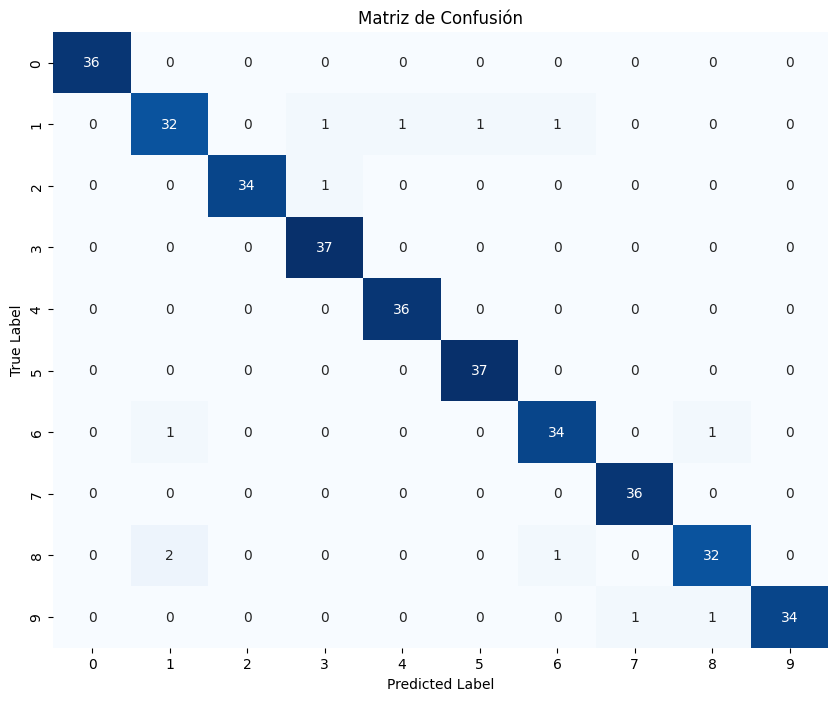

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=digits.target_names, yticklabels=digits.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matriz de Confusión')
plt.show()

### Reporte de Clasificación

In [ ]:
# Classification Report
print("Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in digits.target_names]))

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.91      0.89      0.90        36
           2       1.00      0.97      0.99        35
           3       0.95      1.00      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       0.94      0.94      0.94        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [ ]:
36/36

1.0

In [ ]:
34/36

0.9444444444444444

In [ ]:
2*1*0.9444444444444444/(1+0.9444444444444444)

0.9714285714285714

### Curva ROC y Área Bajo la Curva (AUC)
Para la clasificación multiclase, podemos calcular las curvas ROC para cada clase utilizando una estrategia 'uno contra el resto' (OvR).

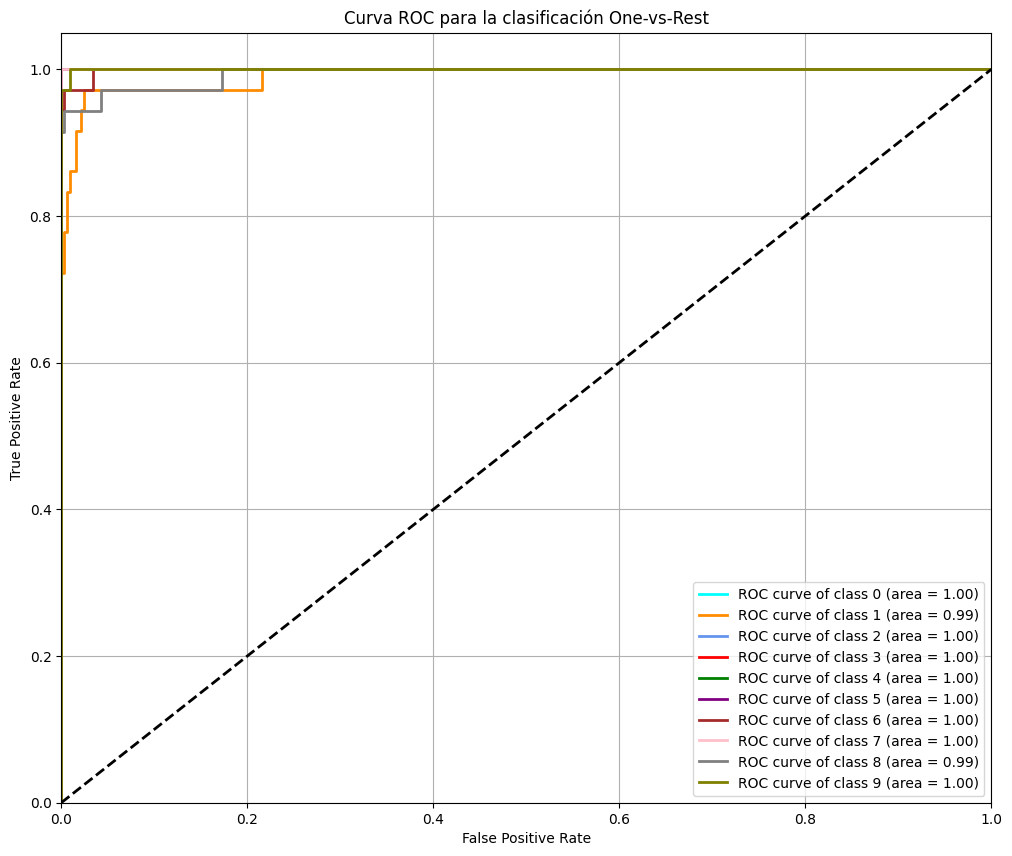

In [ ]:
# ROC Curve and AUC (One-vs-Rest for multi-class)
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_binarized.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 10))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC para la clasificación One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Histograma de Errores (Visualización de Ejemplos Mal Clasificados)

Para visualizar los 'errores', mostraremos un histograma de los dígitos mal clasificados, mostrando qué dígitos se confunden con mayor frecuencia, y algunos ejemplos visuales de estas clasificaciones erróneas.

Total de muestras mal clasificadas: 12


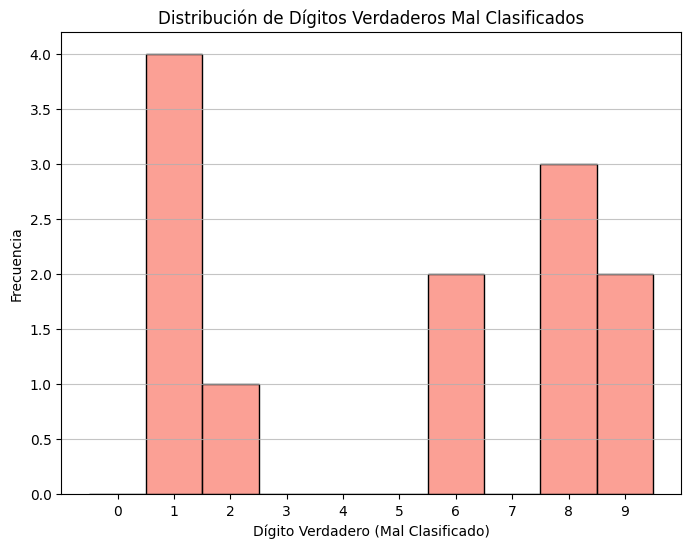

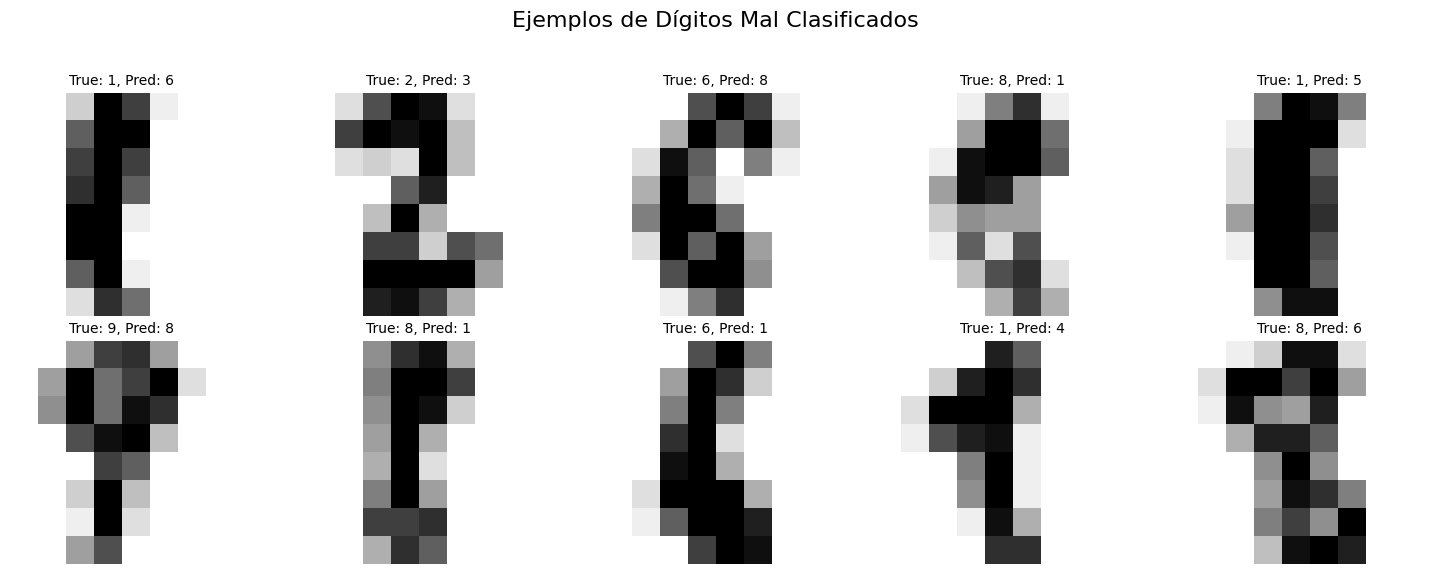

In [ ]:
# Identify misclassified samples
misclassified_indices = np.where(y_pred != y_test)[0]

if len(misclassified_indices) > 0:
    print(f"Total de muestras mal clasificadas: {len(misclassified_indices)}")

    # Histogram of misclassified digits (true labels)
    plt.figure(figsize=(8, 6))
    misclassified_true_labels = y_test[misclassified_indices]
    sns.histplot(misclassified_true_labels, bins=np.arange(-0.5, n_classes + 0.5, 1), kde=False, color='salmon')
    plt.xticks(np.arange(n_classes), digits.target_names)
    plt.xlabel('Dígito Verdadero (Mal Clasificado)')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Dígitos Verdaderos Mal Clasificados')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Visualize some misclassified digits
    num_images_to_show = min(10, len(misclassified_indices)) # Show up to 10 misclassified images
    plt.figure(figsize=(15, 6))
    plt.suptitle('Ejemplos de Dígitos Mal Clasificados', fontsize=16)

    for plot_idx, sample_idx in enumerate(misclassified_indices[:num_images_to_show]):
        plt.subplot(2, 5, plot_idx + 1)
        plt.imshow(X_test[sample_idx].reshape(8, 8), cmap='gray_r')
        plt.title(f"True: {y_test[sample_idx]}, Pred: {y_pred[sample_idx]}", fontsize=10)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("¡No se encontraron muestras mal clasificadas! El modelo es perfecto en el conjunto de prueba.")

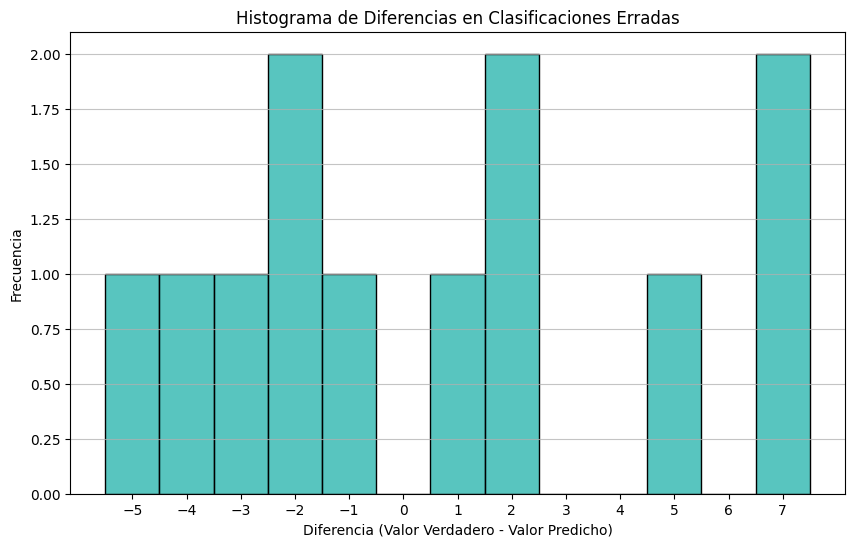

In [ ]:
if len(misclassified_indices) > 0:
    # Calculate the difference between true and predicted labels for misclassified samples
    misclassification_diff = y_test[misclassified_indices] - y_pred[misclassified_indices]

    plt.figure(figsize=(10, 6))
    sns.histplot(misclassification_diff, bins=np.arange(misclassification_diff.min() - 0.5, misclassification_diff.max() + 1.5, 1), kde=False, color='lightseagreen')
    plt.xlabel('Diferencia (Valor Verdadero - Valor Predicho)')
    plt.ylabel('Frecuencia')
    plt.title('Histograma de Diferencias en Clasificaciones Erradas')
    plt.xticks(np.arange(misclassification_diff.min(), misclassification_diff.max() + 1, 1))
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No hay diferencias para graficar ya que no se encontraron muestras mal clasificadas.")

### Histograma de Diferencias para Todas las Muestras

Ahora, visualicemos la diferencia entre los valores verdaderos y predichos para *todas* las muestras en el conjunto de prueba, no solo las mal clasificadas. Esto nos dará una visión general de la distribución de los errores del modelo.

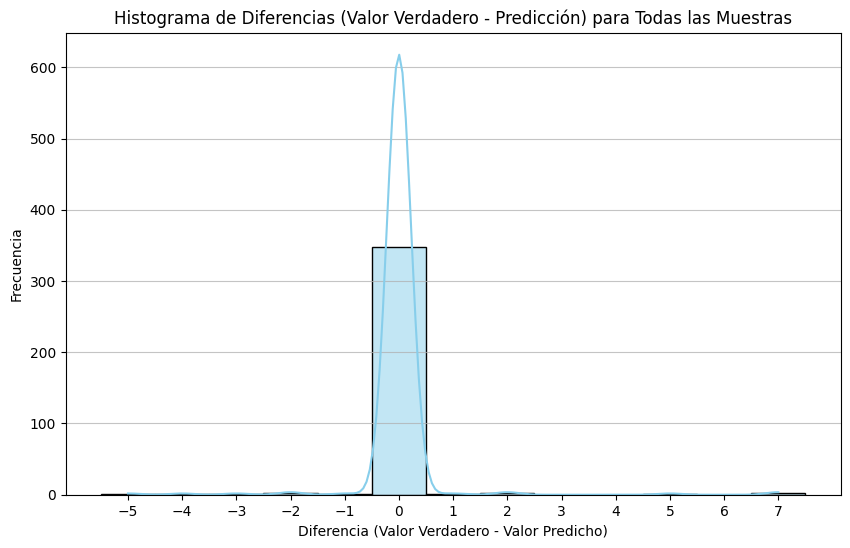

In [ ]:
# Calculate the difference between true and predicted labels for all samples
all_samples_diff = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(all_samples_diff, bins=np.arange(all_samples_diff.min() - 0.5, all_samples_diff.max() + 1.5, 1), kde=True, color='skyblue')
plt.xlabel('Diferencia (Valor Verdadero - Valor Predicho)')
plt.ylabel('Frecuencia')
plt.title('Histograma de Diferencias (Valor Verdadero - Predicción) para Todas las Muestras')
plt.xticks(np.arange(all_samples_diff.min(), all_samples_diff.max() + 1, 1))
plt.grid(axis='y', alpha=0.75)
plt.show()